## Ανάλυση χρονοσειράς ενοικίασης ποδηλάτων

Κάνουμε τα κατάλληλα Import

In [1]:
#list of imports
import pandas as pd
import numpy as np
import csv
import matplotlib.pyplot as plt
from datetime import datetime
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.tsa.statespace.tools import diff
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error as mae
from sklearn.metrics import mean_squared_error as mse


#### Εισάγωγή των δεδομένων απο το csv αρχειο

In [2]:
path = "./data.csv"
df = pd.read_csv(path)

In [3]:
#εκτύπωση του dataframe 
df

,TripId,StartTime,EndTime,StartStationId,EndStationId
0,2616540,2023-02-01 00:28:04,2023-02-01 00:45:18,1,0
1,2616644,2023-02-01 00:34:08,2023-02-01 00:45:49,1,0
2,2616730,2023-02-01 00:39:18,2023-02-01 00:52:06,1,0
3,2617099,2023-02-01 00:59:02,2023-02-01 01:08:31,0,1
4,2617103,2023-02-01 00:59:35,2023-02-01 01:08:19,0,1
...,...,...,...,...,...
8631,3988772,2023-02-28 23:29:08,2023-02-28 23:33:32,1,0
8632,3988863,2023-02-28 23:33:01,2023-02-28 23:36:30,0,1
8633,3988901,2023-02-28 23:35:32,2023-02-28 23:40:22,1,0
8634,3988930,2023-02-28 23:36:58,2023-02-28 23:45:17,0,1


#### Καθαρισμός δεδομένων

Έλεγχος για ελλειπείς τιμές 


In [4]:
#παρατηρώ πως δεν υπάρχουν ελλιπείς τιμές
#Επιπλέον, οι στήλες βρίσκονται σε κατάλληλους τύπους (int για αριθμούς και οbject για τις ημερομηνίες).
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8636 entries, 0 to 8635
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   TripId          8636 non-null   int64 
 1   StartTime       8636 non-null   object
 2   EndTime         8636 non-null   object
 3   StartStationId  8636 non-null   int64 
 4   EndStationId    8636 non-null   int64 
dtypes: int64(3), object(2)
memory usage: 337.5+ KB


Έλεγχος για διπλότυπες εγγραφές

In [5]:
#παρατηρώ πως δεν υπάρχουν διπλότυπες εγγραφές
df.duplicated().sum

<bound method Series.sum of 0       False
1       False
2       False
3       False
4       False
        ...  
8631    False
8632    False
8633    False
8634    False
8635    False
Length: 8636, dtype: bool>

#### Προσαρμογή του Dataframe για την δημιουργία της χρονοσειράς

In [6]:
#Ταξινόμηση των στοιχείων (σε αύξουσα σειρά) με βάση τις στήλες StartTime και EndTime
df[['StartTime', 'EndTime']].sort_values

#μετατροπη των columns σε datetime
df['StartTime'] = pd.to_datetime(df['StartTime'])
df['EndTime'] = pd.to_datetime(df['EndTime'])

#Εισαγωγή τελευταίας γραμμής χωρίς τιμές στα StartStationId EndStationId 
# (χρειάζεται για την εντολή resample στη συνέχεια, διαφορετικά η resample αγνοεί την τελευταία μέτρηση)
extraRowStartTime = pd.to_datetime('2023-03-01 01:00:00')
extraRowEndTime = pd.to_datetime('2023-03-01 02:00:00')
extraRow = {'TripId':'0000000', 'StartTime': extraRowStartTime, 'EndTime': extraRowEndTime, 'StartStationId': 0, 'EndStationId':0}
extraRowIndex = len(df)
df.loc[extraRowIndex] = extraRow

#Ορισμός της στήλης StartTime ως index του df
df.set_index('StartTime', inplace=True)

In [7]:
df

,TripId,EndTime,StartStationId,EndStationId
StartTime,,,,
2023-02-01 00:28:04,2616540,2023-02-01 00:45:18,1,0
2023-02-01 00:34:08,2616644,2023-02-01 00:45:49,1,0
2023-02-01 00:39:18,2616730,2023-02-01 00:52:06,1,0
2023-02-01 00:59:02,2617099,2023-02-01 01:08:31,0,1
2023-02-01 00:59:35,2617103,2023-02-01 01:08:19,0,1
...,...,...,...,...
2023-02-28 23:33:01,3988863,2023-02-28 23:36:30,0,1
2023-02-28 23:35:32,3988901,2023-02-28 23:40:22,1,0
2023-02-28 23:36:58,3988930,2023-02-28 23:45:17,0,1


#### Ορισμός της χρονοσειράς

In [8]:
#επιστρέφει την διαφόρα των στηλών EndStationId και StartStationId στο χρονικο διάστημα Τ (ορισμά της συνάρτησης)
def createTimeSeries(T):
    return pd.DataFrame(df['EndStationId'].resample(T).sum() - df['StartStationId'].resample(T).sum(), columns = ['demand'])

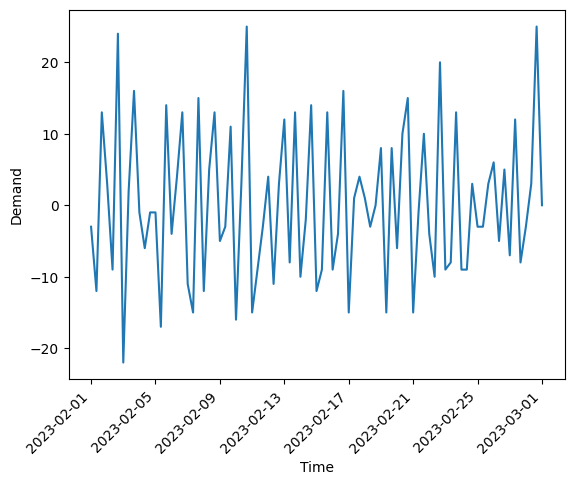

In [9]:
#Eνδεικτικα εμφανίζεται η χρονοσειρά της ζήτησης ποδηλάτων ανα 8 ώρες
ts = createTimeSeries('8h')

plt.xlabel("Time")
plt.xticks(rotation=45, ha='right')
plt.ylabel("Demand")
plt.plot(ts)
plt.show()

#### Έλεγχoς αν η χρονοσειρά παρουσιάζει τάση ή εποχικότητα:

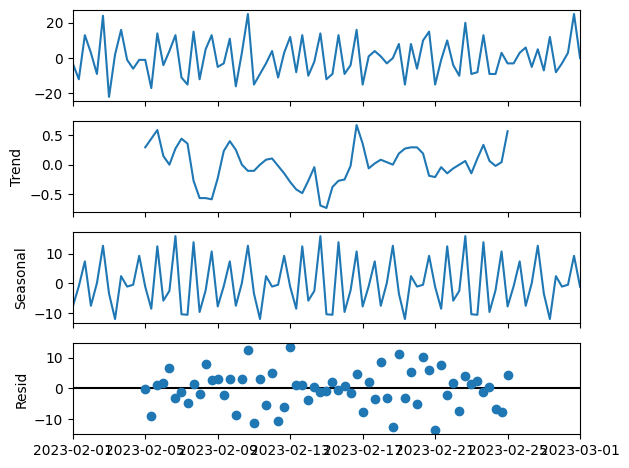

In [10]:
result = seasonal_decompose(ts, model='additive')
result.plot()
plt.show()

Παρατηρώ πως η χρονοσειρά ενώ δεν φαίνεται να έχει ταση παρουσιάζει εποχικότητα.

Έλεγχος με διαγράμματα acf και pacf:

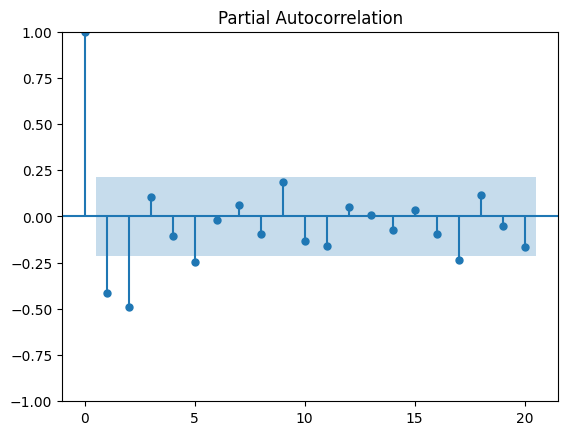

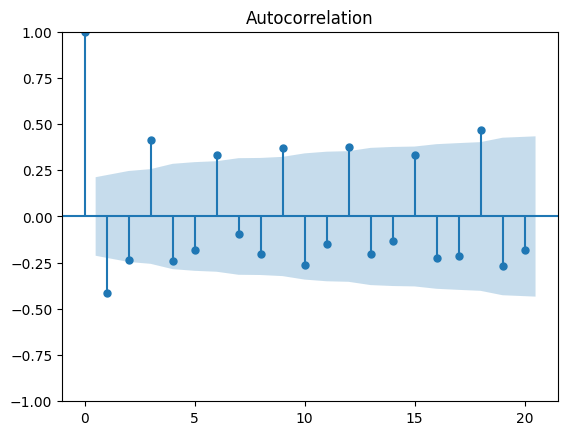

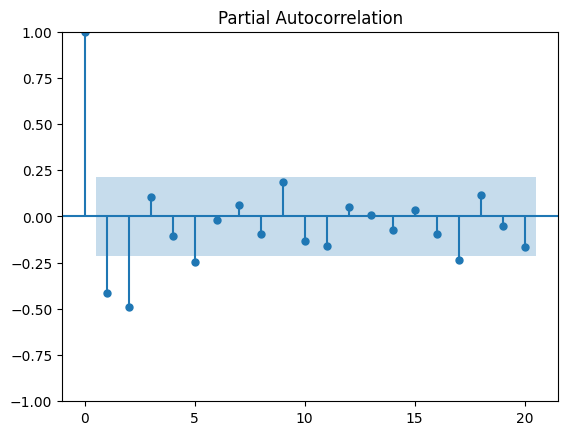

In [11]:
#ACF και PACF διάγραμμα της χρονοσειράς
plot_acf(ts)
plot_pacf(ts)

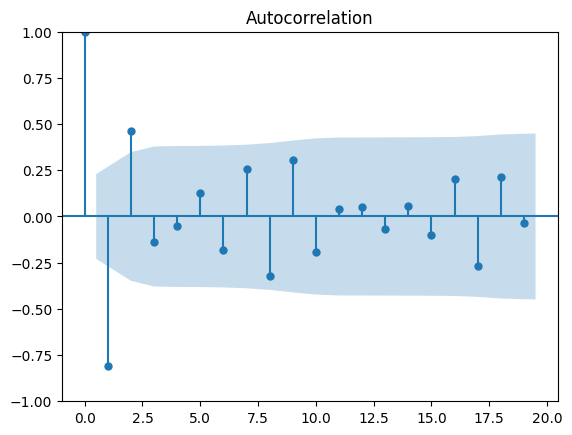

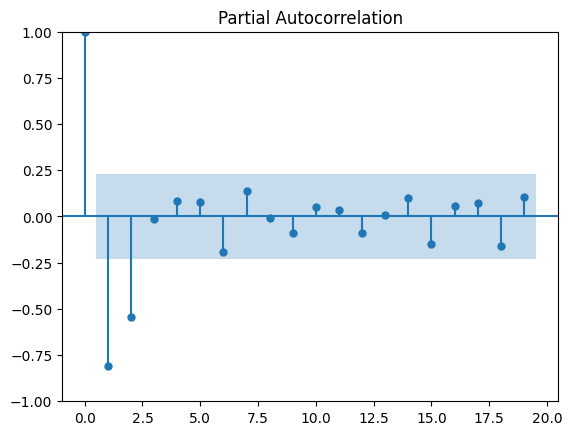

In [12]:
#ACF και PACF διάγραμμα της χρονοσειράς με τελεστή διαφοράς
plot_acf(diff(ts, k_diff=12))
plot_pacf(diff(ts, k_diff=12))
plt.show()

Παρατηρώ πως με εξαίρεση μερικά μεγάλες τιμές στην αρχή, σταδιακά μειώνονται οι τιμες της αυτοσυσχέτισης.
Επιπλέον, με τον τελεστή διαφοράς οι τιμές της αυτοσυσχέτισης πλησιαζουν πολυ γρήγορα στο 0.

##### Παρατήρηση

Τα παραπάνω διαγράμματα προκύπτουν με βάση την τιμη Τ = 8Η (ομάδοποίηση των δεδομένων ανα διάστημα 8 ωρών).

Ωστόσο, μπορούμε να υποθέσουμε πως για οποιοδήποτε διάστημα θα έχουμε παρόμοια συμπεράσματα σχετικά με την ύπαρξη τάσης ή εποχικότητας στη χρονοσειρά (εφόσον αυτό δεν μειώνει κατά πολύ το πλήθος των δειγμάτων).

Στην συνέχεια της άσκησης ως μέγιστο όριο διαστήματος θεωρώ τις 12 ώρες καθώς για Τ = 12Η ο αριθμός των δειγμάτων  είναι σχετικά μικρός αριθμός (ίσος με 57)

In [13]:
tsWithMaxTValue = createTimeSeries('12h')
print(tsWithMaxTValue.shape)

(57, 1)


#### Προβλέψεις

##### Ορισμός δεδομένων εκπαίδευσης και δεδομένων ελέγχου

In [14]:
#Επιστρέφει τα στοιχεία της χρονοσειράς που αποτελούν το train set και το test set 
def getTrainAndTestSet(timeSeries, percentage):
    trainPercentageValues = round(len(timeSeries)*percentage)
    testPercentageValues = round(len(timeSeries)*(1-percentage))
    return timeSeries.iloc[:trainPercentageValues], timeSeries.iloc[-testPercentageValues:]

##### Προβλεπτικά μοντέλα (εκθετική εξομάλυνση, Arima)

In [15]:
#Επιστρέφει τις προβλέψεις των προγνωστικών μοντέλων 
def createPrognosticModels(train, test, orderArima, seasonal_orderSarimax):
    #εκπαίδευση προγνωστικών μοντέλων
    autoreg = AutoReg(train, lags=1, seasonal=True).fit()
    expSmooth = ExponentialSmoothing(train, seasonal='add').fit()
    arima = ARIMA(train, order=orderArima, trend='c').fit()
    sarimax = SARIMAX(train, order=orderArima, seasonal_order=seasonal_orderSarimax, trend='c').fit(disp=False)
    
    startTime = len(train)
    endTime = len(train) + len(test) - 1

    #προβλεψεις μοντέλων
    autoreg_pred = autoreg.predict(start = startTime, end = endTime, dynamic=False)
    expSmooth_pred = expSmooth.predict(start = startTime, end = endTime)
    arima_pred = arima.predict(start = startTime, end = endTime, dynamic=False)
    sarimax_pred = sarimax.predict(start = startTime, end = endTime, dynamic=False)

    return autoreg_pred, expSmooth_pred, arima_pred, sarimax_pred

In [16]:
def showDiagrams(timeSeries, autoreg_pred, expSmooth_pred, arima_pred, sarimax_pred, orderArima, seasonal_orderSarimax):
    #καθορισμός μεγέθους του διαγράμματος
    plt.figure(figsize=(12,6))

    #εμφάνιση της χρονοσειράς και των μοντέλων 
    plt.plot(timeSeries, '-', label='Original Data')
    plt.plot(autoreg_pred, '-', label='Auto Regression', color='purple')
    plt.plot(expSmooth_pred, '-', label='Exponential Smoothing', color='green')
    plt.plot(arima_pred, '-', label='ARIMA' + str(orderArima), color='red')
    plt.plot(sarimax_pred, '-', label='SARIMAX' + str(orderArima) + str(seasonal_orderSarimax), color='orange')
    
    plt.xticks(rotation=45)
    plt.legend()
    plt.show()

In [17]:
#Εμφανίζει τα MAE και RMSE για τις προβλέψεις των μοντέλων με ακριβεια 3 δεκαδικών ψηφίων
def printMAEAndRMSE(test, autoreg_pred, expSmooth_pred, arima_pred, sarimax_pred):
    
    print('MAE:')
    print(f'Αuto Regression: {round(mae(test, autoreg_pred), 3)}')
    print(f'Exponential Smoothing: {round(mae(test, expSmooth_pred), 3)}')
    print(f'ARIMA: {round(mae(test, arima_pred), 3)}')
    print(f'SARIMAX: {round(mae(test, sarimax_pred), 3)}')
    print('-----------------------')
    print('RMSE:')
    print(f'Αuto Regression: {round(np.sqrt(mse(test, autoreg_pred)), 3)}')
    print(f'Exponential Smoothing: {round(np.sqrt(mse(test, expSmooth_pred)), 3)}')
    print(f'ARIMA: {round(np.sqrt(mse(test, arima_pred)), 3)}')
    print(f'SARIMAX: {round(np.sqrt(mse(test, sarimax_pred)), 3)}')

##### Παρατήρηση
Για την εύρεση των παραμέτρων στα μοντέλα arima και sarima χρησιμοποιήθηκε το auto arima. Ωστόσο, επειδή μπορεί να παρουσιαστούν δυσκολίες με την     εντολη του install του auto arima επέλεξα να μην τις συμπεριλάβω. 

Παρόλαυτα, παρακάτω παρατίθεται ο σχετικός κωδικάς (σε σχόλια ώστε να μην τρεξει μαζι με το υπόλοιπο πρόγραμμα).

In [18]:
# # #Απαραίτητο install για την λειτουργία του auto_arima
# # %pip install auto_arima

# import pmdarima as pm

# for hour in ['2H', '4H', '6H', '8H']:
#     ts = createTimeSeries(hour)
#     train, test = getTrainAndTestSet(ts, 70/100)
#     print(pm.auto_arima(train, stepwise = False, seasonal = True))

#### Έλεγχος αποτελεσμάτων:

/home/dim/Documents/venvs/data_analysis_project/lib/python3.14/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/home/dim/Documents/venvs/data_analysis_project/lib/python3.14/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/home/dim/Documents/venvs/data_analysis_project/lib/python3.14/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/home/dim/Documents/venvs/data_analysis_project/lib/python3.14/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA pa

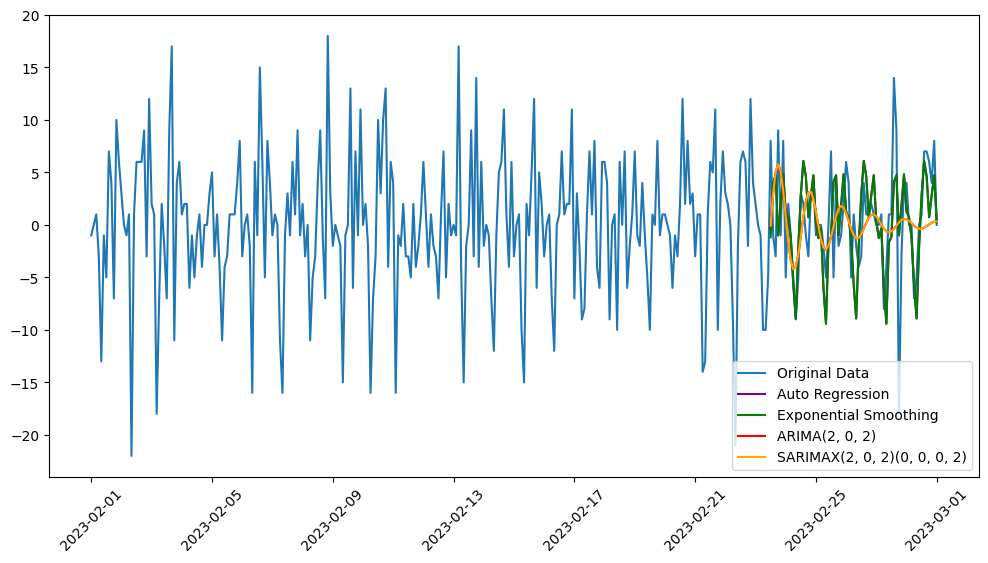

MAE:
Αuto Regression: 3.337
Exponential Smoothing: 3.346
ARIMA: 3.638
SARIMAX: 3.638
-----------------------
RMSE:
Αuto Regression: 4.509
Exponential Smoothing: 4.533
ARIMA: 4.92
SARIMAX: 4.92


In [19]:
ts = createTimeSeries('2h')
train, test = getTrainAndTestSet(ts, 80/100)

orderArima = (2,0,2)
seasonal_orderSarimax = (0, 0, 0, 2)
autoreg_pred, expSmooth_pred, arima_pred, sarimax_pred = createPrognosticModels(train, test, orderArima, seasonal_orderSarimax)
showDiagrams(ts, autoreg_pred, expSmooth_pred, arima_pred, sarimax_pred, orderArima, seasonal_orderSarimax)
printMAEAndRMSE(test, autoreg_pred, expSmooth_pred, arima_pred, sarimax_pred)

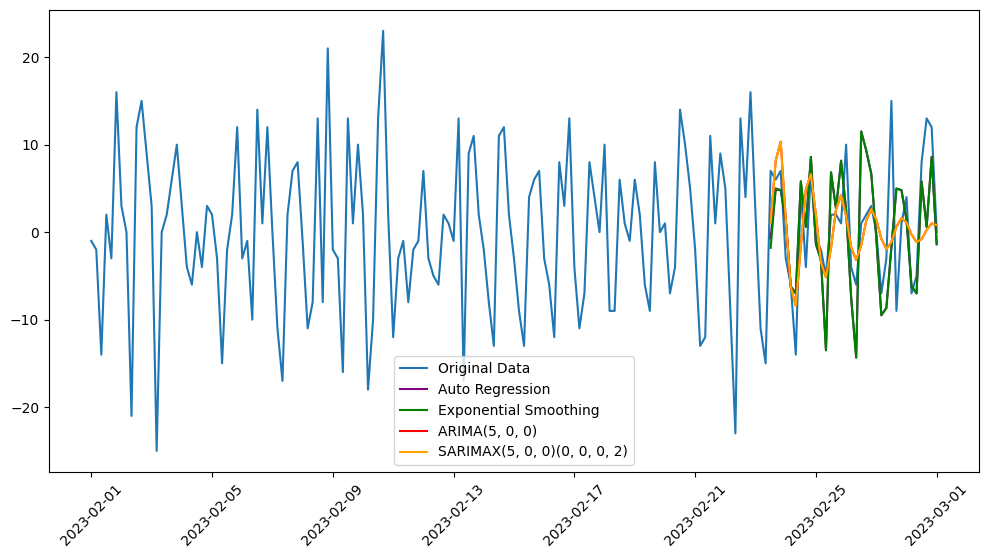

MAE:
Αuto Regression: 4.742
Exponential Smoothing: 4.773
ARIMA: 4.375
SARIMAX: 4.375
-----------------------
RMSE:
Αuto Regression: 6.257
Exponential Smoothing: 6.313
ARIMA: 5.879
SARIMAX: 5.879


In [20]:
ts = createTimeSeries('4h')
train, test = getTrainAndTestSet(ts, 80/100)

orderArima = (5,0,0)
seasonal_orderSarimax = (0, 0, 0, 2)
autoreg_pred, expSmooth_pred, arima_pred, sarimax_pred = createPrognosticModels(train, test, orderArima, seasonal_orderSarimax)
showDiagrams(ts, autoreg_pred, expSmooth_pred, arima_pred, sarimax_pred, orderArima, seasonal_orderSarimax)
printMAEAndRMSE(test, autoreg_pred, expSmooth_pred, arima_pred, sarimax_pred)


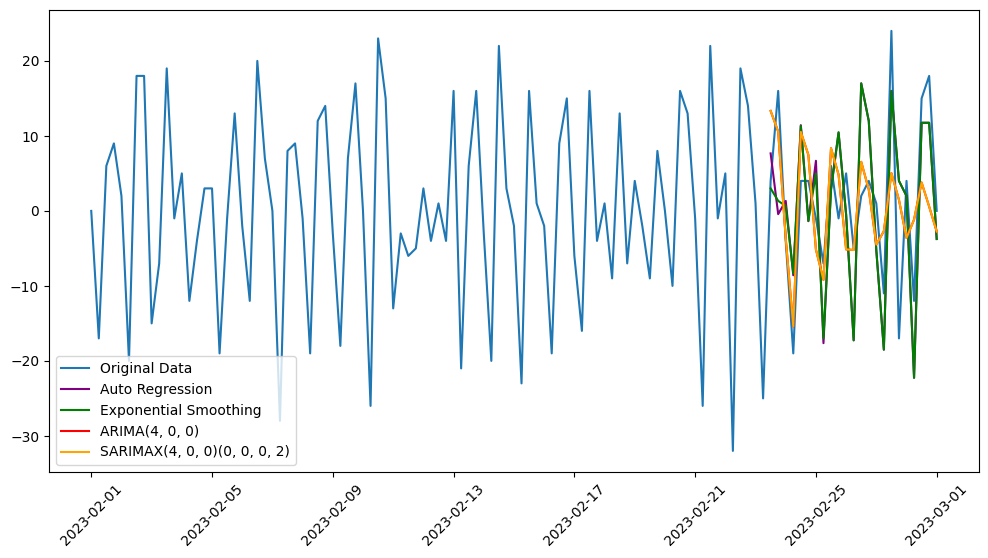

MAE:
Αuto Regression: 8.277
Exponential Smoothing: 7.975
ARIMA: 6.97
SARIMAX: 6.97
-----------------------
RMSE:
Αuto Regression: 9.46
Exponential Smoothing: 9.22
ARIMA: 8.803
SARIMAX: 8.803


In [21]:
ts = createTimeSeries('6h')
train, test = getTrainAndTestSet(ts, 80/100)

orderArima = (4,0,0)
seasonal_orderSarimax = (0, 0, 0, 2)
autoreg_pred, expSmooth_pred, arima_pred, sarimax_pred = createPrognosticModels(train, test, orderArima, seasonal_orderSarimax)
showDiagrams(ts, autoreg_pred, expSmooth_pred, arima_pred, sarimax_pred, orderArima, seasonal_orderSarimax)
printMAEAndRMSE(test, autoreg_pred, expSmooth_pred, arima_pred, sarimax_pred)

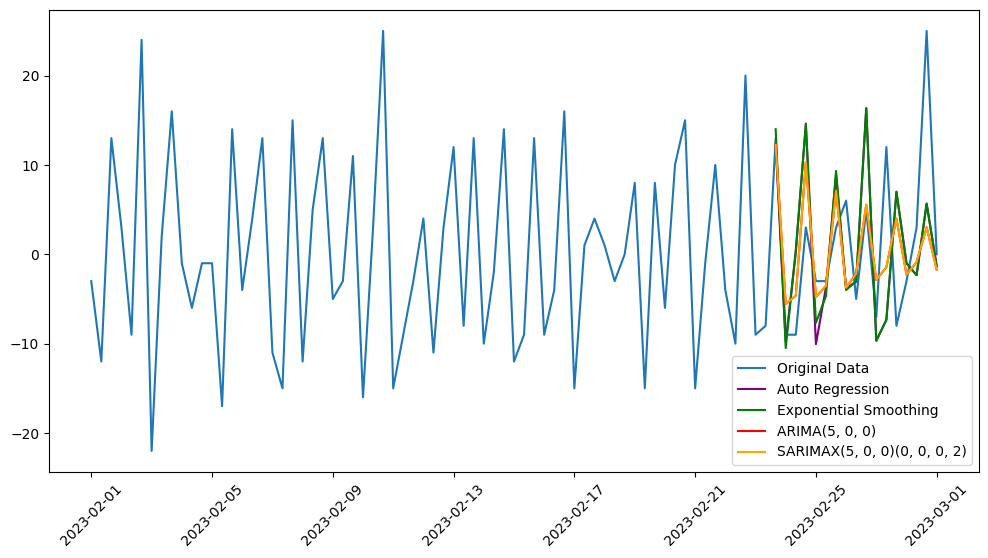

MAE:
Αuto Regression: 7.296
Exponential Smoothing: 7.323
ARIMA: 5.487
SARIMAX: 5.487
-----------------------
RMSE:
Αuto Regression: 9.545
Exponential Smoothing: 9.508
ARIMA: 7.866
SARIMAX: 7.866


In [22]:
ts = createTimeSeries('8h')
train, test = getTrainAndTestSet(ts, 80/100)

orderArima = (5,0,0)
seasonal_orderSarimax = (0, 0, 0, 2)
autoreg_pred, expSmooth_pred, arima_pred, sarimax_pred = createPrognosticModels(train, test, orderArima, seasonal_orderSarimax)
showDiagrams(ts, autoreg_pred, expSmooth_pred, arima_pred, sarimax_pred, orderArima, seasonal_orderSarimax)
printMAEAndRMSE(test, autoreg_pred, expSmooth_pred, arima_pred, sarimax_pred)

#### Συμπεράσματα:

Παρατηρώ πως για Τ = 2ώρες τα μοντέλα auto regression και  exponential smoothing φαίνεται να κάνουν καλύτερες προβλέψεις σε σχέση με τα μοντέλα arima και sarimax, διότι έχουν χαμηλότερες τιμές mae και rmse. Ωστόσο, για τα χρονικά διάστηματα Τ = 4 ώρες, Τ = 6 ώρες, Τ = 8ώρες τα μοντέλα arima και sarimax έχουν μικρότερες τιμές και συνεπώς είναι πιο αποδοτικά.

Ανάμεσα στα μοντέλα arima και sarimax, το sarimax φαίνεται να κάνει καλύτερες προβλεψεις. Παρόλο που για Τ = 2 ώρες, Τ = 4 ώρες το sarimax έχει μεγαλύτερες τιμές στα mae kai rmse η διαφορά των τιμών μεταξύ των 2 μοντέλων είναι πολύ μικρή (ακόμη και στα διαγράμματα τα 2 μοντέλα φαινεται σχεδόν να ταυτίζονται). Επιπλέον, όταν Τ = 6 ώρες και Τ = 8 ώρες το μοντέλο sarimax παρουσιάζει μικρότερες τιμές mae και rmse.

Επομένως, από όλα τα μοντέλα που χρησιμοιήθηκαν το sarimax κάνει τις καλύτερες προβλέψεις.